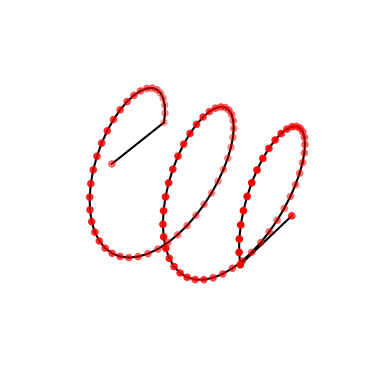

In [1]:
import numpy as np
import dismech

geom = dismech.GeomParams(rod_r0=5e-3,
                          shell_h=0)

material = dismech.Material(density=1200,
                            youngs_rod=5e6,
                            youngs_shell=0,
                            poisson_rod=0.5,
                            poisson_shell=0)

static_2d_sim = dismech.SimParams(static_sim=False,
                                  two_d_sim=True,
                                  use_mid_edge=False,
                                  use_line_search=False,
                                  show_floor=False,
                                  log_data=True,
                                  log_step=1,
                                  dt=1e-3,
                                  max_iter=25,
                                  total_time=1.0,
                                  plot_step=1,
                                  tol=1e-4,
                                  ftol=1e-4,
                                  dtol=1e-2)

env = dismech.Environment()
env.add_force('gravity', g=np.array([0.0, 0.0, -9.81]))
# env.add_force('damping', eta=1)

geo = dismech.Geometry.from_txt('../tests/resources/slinky/slinky.txt')

robot = dismech.SoftRobot(geom, material, geo, static_2d_sim, env)

In [2]:
fixed_points = np.array([0, 1, robot.n_nodes-2, robot.n_nodes-1])
robot = robot.fix_nodes(fixed_points)
stepper = dismech.ImplicitEulerTimeStepper(robot)
robots, t_arr, f_norms = stepper.simulate()
qs = np.stack([robot.state.q for robot in robots])
vs = np.stack([robot.state.u for robot in robots])
t_arr = np.array(t_arr)

iter: 1, error: 0.069
iter: 2, error: 0.000
current_time:  0.001
iter: 1, error: 0.127
iter: 2, error: 0.000
current_time:  0.002
iter: 1, error: 0.188
iter: 2, error: 0.000
current_time:  0.003
iter: 1, error: 0.249
iter: 2, error: 0.000
current_time:  0.004
iter: 1, error: 0.308
iter: 2, error: 0.001
current_time:  0.005
iter: 1, error: 0.366
iter: 2, error: 0.001
current_time:  0.006
iter: 1, error: 0.423
iter: 2, error: 0.001
current_time:  0.007
iter: 1, error: 0.477
iter: 2, error: 0.001
current_time:  0.008
iter: 1, error: 0.530
iter: 2, error: 0.002
current_time:  0.009000000000000001
iter: 1, error: 0.581
iter: 2, error: 0.002
current_time:  0.010000000000000002
iter: 1, error: 0.631
iter: 2, error: 0.002
current_time:  0.011000000000000003
iter: 1, error: 0.678
iter: 2, error: 0.002
current_time:  0.012000000000000004
iter: 1, error: 0.724
iter: 2, error: 0.002
current_time:  0.013000000000000005
iter: 1, error: 0.768
iter: 2, error: 0.003
current_time:  0.014000000000000005


In [5]:
options = dismech.AnimationOptions(title='Helix (N=50)', plot_step=10)

fig = dismech.get_interactive_animation_plotly(robot, t_arr, qs, options)
fig.show()

101


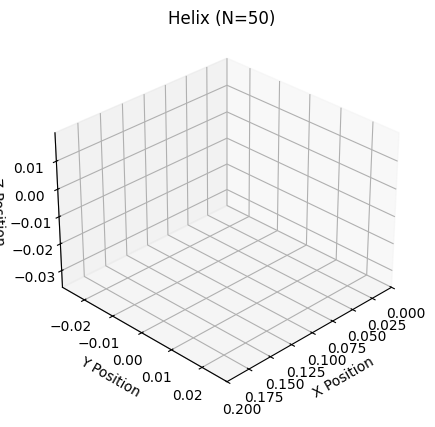

In [6]:
ani = dismech.get_animation(robot, t_arr, qs, options)
ani.save('slinky.gif')

In [7]:
# get centroid trajectory (correct)
T = qs.shape[0]

qs_nodes = qs[:, :robot.n_nodes * 3]                    # (T, 3*n)
nodes = qs_nodes.reshape(T, robot.n_nodes, 3)           # (T, n, 3)  where last dim is (x,y,z)
centroid_traj = nodes.mean(axis=1)                      # (T, 3)

vs_nodes = vs[:, :robot.n_nodes * 3]
nodes_vel = vs_nodes.reshape(T, robot.n_nodes, 3)       # (T, n, 3)
centroid_vel = nodes_vel.mean(axis=1)                   # (T, 3)

# slinky length from last node x-coordinate (or use a known constant L if you have it)
slinky_len = nodes[-1, -1, 0]                           # x of last node at final time

start_block = np.tile([0.0, 0.0, 0.0], (T, 1))          # (T, 3)
end_block   = np.tile([slinky_len, 0.0, 0.0], (T, 1))   # (T, 3)

centerline_nodes_traj = np.hstack([start_block, centroid_traj, end_block])  # (T, 9)


centerline_node_vel = np.hstack([
    np.zeros((T, 3)),
    centroid_vel,
    np.zeros((T, 3))
])                                                      # (T, 9)


xs_centerline = np.hstack([
    centerline_nodes_traj,
    centerline_node_vel
])                                                      # (T, 9+2+9+2) = (T, 22)

print("centerline state shape:", xs_centerline.shape)
print("centroid_traj[0], centroid_traj[-1]:", centroid_traj[0], centroid_traj[-1])

np.savez("slinky_centerline_3_nodes_truth.npz", xs_centerline=xs_centerline)

centerline state shape: (1001, 18)
centroid_traj[0], centroid_traj[-1]: [1.00000000e-01 6.80283716e-20 2.46639216e-03] [ 1.00000000e-01 -1.73302277e-16 -4.95203765e-03]


In [8]:
x = qs_nodes[:, 0::3]
y = qs_nodes[:, 1::3]
z = qs_nodes[:, 2::3]
centroid_alt = np.stack([x.mean(axis=1), y.mean(axis=1), z.mean(axis=1)], axis=1)

print("max abs diff:", np.max(np.abs(centroid_traj - centroid_alt)))

max abs diff: 6.938893903907228e-17
